In [6]:
import pandas as pd
dataset = pd.read_csv('../data/train.csv', nrows=5000)

In [7]:
dataset.head()

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


In [8]:
dataset.toxic.value_counts()

toxic
0    4497
1     503
Name: count, dtype: int64

<Axes: title={'center': 'Class Distribution : Toxic vs Non-toxic'}, xlabel='toxic'>

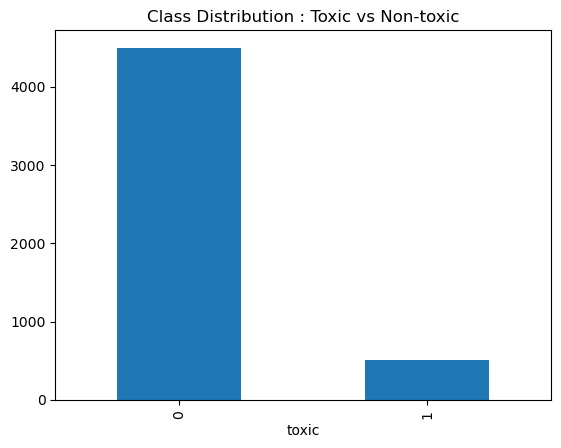

In [9]:
dataset.toxic.value_counts().plot(kind='bar', title = 'Class Distribution : Toxic vs Non-toxic')

In [10]:
def comment_text(text) :
    return len(text)
dataset['text_length'] = dataset['comment_text'].apply(comment_text)
dataset.head()

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate,text_length
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0,264
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0,112
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0,233
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0,622
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0,67


In [11]:
import seaborn as sns

<Axes: xlabel='text_length', ylabel='Count'>

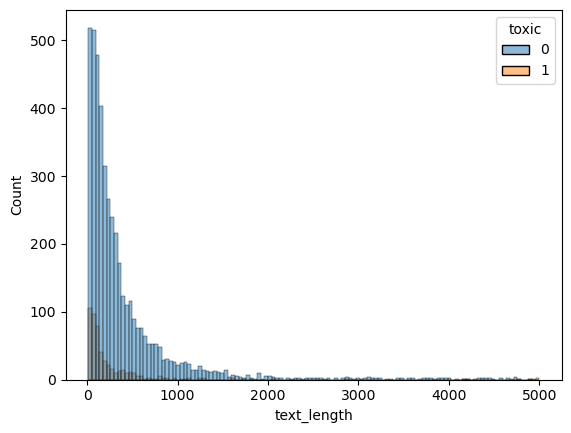

In [12]:
sns.histplot(data = dataset, x = 'text_length', hue = 'toxic')

In [13]:
dataset_contains_http = dataset[dataset['comment_text'].str.contains('http', regex=True, na=False)]
print(dataset_contains_http)

                    id                                       comment_text  \
22    000c0dfd995809fa  "\n\n Snowflakes are NOT always symmetrical! \...   
33    001363e1dbe91225  I was able to post the above list so quickly b...   
73    002c9cccf2f1d05b  "\n Ambiguous ? \nSo Mabuska Irish can mean mo...   
91    0038f191ffc93d75  Transliteration of Russian place names\nIn wri...   
101   003fa0c68deca750  Check the following websites:\n\nhttp://www.ir...   
...                ...                                                ...   
4739  0c95698a862001f4  "\nCopyright problem: Intonarumori\nHello, and...   
4857  0cdb77759fbb61fe  The Ediacaran has been upgraded to a bonafide ...   
4873  0ce69c2fa9d8bfbe  I dont know where to put this \n\nPentagon bri...   
4897  0cf8139e07493617  SHUT UP HO AND READ THIS http://profile.myspac...   
4905  0cfbe46f2f16c132  This is not a treasure hunt nor a mystery. The...   

      toxic  severe_toxic  obscene  threat  insult  identity_hate  text_len

In [14]:
dataset_contains_newline = dataset[dataset['comment_text'].str.contains('\n', regex=True, na=False)]
print(dataset_contains_newline)

                    id                                       comment_text  \
0     0000997932d777bf  Explanation\nWhy the edits made under my usern...   
3     0001b41b1c6bb37e  "\nMore\nI can't make any real suggestions on ...   
5     00025465d4725e87  "\n\nCongratulations from me as well, use the ...   
10    0005300084f90edc  "\nFair use rationale for Image:Wonju.jpg\n\nT...   
11    00054a5e18b50dd4  bbq \n\nbe a man and lets discuss it-maybe ove...   
...                ...                                                ...   
4994  0d39bef98c00f870  "\n\n Recap \n\nI decided to withhold further ...   
4995  0d39d2eaa40a6241  "\n\nHello Marcruhwedell, and Welcome to Wikip...   
4997  0d3bb1f12d90a6a2  No, it's not a delayed reaction\n\nI just happ...   
4998  0d3be13abf1bec52  "\n\nA slight difference with you\nI have to d...   
4999  0d3c720db297b5a3  "\n\nNonsense.  The truth is NO schools give s...   

      toxic  severe_toxic  obscene  threat  insult  identity_hate  text_len

In [15]:
dataset_contains_spaces = dataset[dataset['comment_text'].str.contains('   ', regex=True, na=False)]
print(dataset_contains_spaces)

                    id                                       comment_text  \
23    000c6a3f0cd3ba8e  "\n\n The Signpost: 24 September 2012 \n\n Rea...   
24    000cfee90f50d471  "\n\nRe-considering 1st paragraph edit?\nI don...   
27    000ffab30195c5e1  Yes, because the mother of the child in the ca...   
29    0010833a96e1f886  "== A barnstar for you! ==\n\n  The Real Life ...   
35    00148d055a169b93  "\n\nNot at all, you are making a straw man ar...   
...                ...                                                ...   
4964  0d22096912a1c17e  ", and use the confusing, redundent, yet commo...   
4973  0d286abe7682c934  Ok, you says that have created a local file in...   
4981  0d31383c6515cd67  "\n\nSpeedy deletion of Vanilla (French band)\...   
4984  0d3338457bd33250  Entirely correct per the source. Move on.   (s...   
4987  0d33b227369ba45d  This article is not like an encyclopedia at al...   

      toxic  severe_toxic  obscene  threat  insult  identity_hate  text_len

In [16]:
import re
dataset_contains_caps = dataset[dataset['comment_text'].str.contains(r"\b[A-Z]{3,}\b", regex=True, na=False)]
print(dataset_contains_caps)

                    id                                       comment_text  \
0     0000997932d777bf  Explanation\nWhy the edits made under my usern...   
1     000103f0d9cfb60f  D'aww! He matches this background colour I'm s...   
6     0002bcb3da6cb337       COCKSUCKER BEFORE YOU PISS AROUND ON MY WORK   
10    0005300084f90edc  "\nFair use rationale for Image:Wonju.jpg\n\nT...   
12    0005c987bdfc9d4b  Hey... what is it..\n@ | talk .\nWhat is it......   
...                ...                                                ...   
4976  0d2badc0f2416fe3  "\nWelcome!\n\nHello, , and welcome to Wikiped...   
4977  0d2d2c64b2752e93  ", 15 May 2008 (UTC)\n\nPrince Felix of Schwar...   
4986  0d33729ccf8ffb57  STOP IT!!!!!!!!!! \n\nSTOP DELETING STUFF I AM...   
4991  0d35f6a96cb98dc2  IT IS VERY LIKELY THESE WILL BE MOVING SOON TO...   
4993  0d36cc183fd48152  "\n\n Why is the lingo/doublespeak/racist word...   

      toxic  severe_toxic  obscene  threat  insult  identity_hate  text_len

In [17]:
dataset_contains_punctuations = dataset[dataset['comment_text'].str.contains(r"([^\w\s])\1{2,}", regex=True, na=False)]
print(dataset_contains_punctuations)

                    id                                       comment_text  \
12    0005c987bdfc9d4b  Hey... what is it..\n@ | talk .\nWhat is it......   
20    000b08c464718505  "\n\n Regarding your recent edits \n\nOnce aga...   
42    001810bf8c45bf5f  You are gay or antisemmitian? \n\nArchangel WH...   
44    001956c382006abd  I'm Sorry \n\nI'm sorry I screwed around with ...   
48    001cadfd324f8087  "\nAs for your claims of ""stalking"", that is...   
...                ...                                                ...   
4984  0d3338457bd33250  Entirely correct per the source. Move on.   (s...   
4986  0d33729ccf8ffb57  STOP IT!!!!!!!!!! \n\nSTOP DELETING STUFF I AM...   
4994  0d39bef98c00f870  "\n\n Recap \n\nI decided to withhold further ...   
4995  0d39d2eaa40a6241  "\n\nHello Marcruhwedell, and Welcome to Wikip...   
4996  0d3b57f3b2db3f03  ...that's why I did ....cheers,   (talk · cont...   

      toxic  severe_toxic  obscene  threat  insult  identity_hate  text_len

/var/folders/2v/86_f8qdj0nld18dgy92gvql80000gn/T/ipykernel_51406/1865407977.py:1: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  dataset_contains_punctuations = dataset[dataset['comment_text'].str.contains(r"([^\w\s])\1{2,}", regex=True, na=False)]


In [18]:
dataset_contains_htmltags = dataset[dataset['comment_text'].str.contains('<', na=False)]
print(dataset_contains_htmltags)

                    id                                       comment_text  \
661   01cbab2392e63259  "\n\n Wikipedia:Articles for deletion/Cheongye...   
3840  0a3ae987022ad45d  "\nBut Stranger Danger is so fun (. Good luck ...   

      toxic  severe_toxic  obscene  threat  insult  identity_hate  text_length  
661       0             0        0       0       0              0         4348  
3840      0             0        0       0       0              0           63  


In [19]:
# Noise audit findings:
# - 139 comments contain URLs (http)
# - 2943 comments contain newlines (\n)
# - 0 proper HTML tags found in sample (2 stray '<' chars, non-HTML usage)
# - 1441 comments contain all-caps words
# - 636 comments contain repeated punctuation
# Note: HTML tags may appear in full 159k dataset but not in this 5k sample

In [20]:
# Edge cases to test every cleaning function built. 
# Covered: URLs, HTML tags, newlines, all-caps, repeated punctuation, empty 
# string, only spaces, mixed noise, AAVE phrasing, sarcasm, and emoji.

str1 = "hey, there! checkout the major discount ever on shoes!!! visit : https://www.shoepoint.com First come, first serve service."
str2 = "Html is a very easy to learn language, the building blocks of it are its tags such as </head> <body> <p> <br> and many more."
str3 = "Smriti this side.\n Building her first ever END TO END deployed project.\n\n Thankyou."
str4 = "WHAT THEE HELLLL? HOW CAN SOMEONE DO THIS????"
str5 = "I'm so excited to meet you this weekend,,, gonna have a lot of fun!!!!\n yayyyyy"
str6 = ""
str7 = "                "
str8 = "In the end, it's all about\n\n\n the DISCOUNT OFFERED!!!! we are so happy to announce the best deal of this year\n\n visit us at https://bookstore.com <br>"
str9 = "Nopessss, neverrrr❌"
str10 = "He ain't going"
str11 = "Visit our site NOW!!! https://deals4you.com <div>Best prices guaranteed</div>"
str12 = "<html><body><h1>WELCOME</h1><p>This is AMAZING!!!</p></body></html>"
str13 = "okayyyy fineeee I'll do it later..... maybeeeeee"
str14 = "😂😂😂 that was sooo funnyyyyy!!!"
str15 = "Bruh he be acting weird all the time 💀"
str16 = "She done told you already, why you asking again?"
str17 = "I ain't got no time for this nonsense 😤"
str18 = "Oh great, another Monday morning... just what I needed 🙃"
str19 = "   Mixed   spacing   everywhere     with   random   gaps   "
str20 = "\n\n\nOnly newlines here\n\n\n"
str21 = "CLICK HERE 👉 https://spammy-link.com $$$ LIMITED OFFER $$$"
str22 = "<p>Paragraph with <a href='link'>link</a> and <br> line break</p>"
str23 = "Combination!!! Visit NOW: https://combo.com <br>\n BEST DEAL EVER!!!! 😂😂"
str24 = "Sureeee, because that makes TOTAL sense... not."
str25 = "LOL!!! THIS IS CRAZYYYYY 😂😂😂 CHECK THIS OUT: https://lol.com"

In [21]:
import sys
sys.path.append('../../backend_api/app')
from services.preprocessing import clean_text
print(clean_text(str1))
print(clean_text(str2))
print(clean_text(str3))
print(clean_text(str4))
print(clean_text(str5))
print(clean_text(str6))
print(clean_text(str7))
print(clean_text(str8))
print(clean_text(str9))
print(clean_text(str10))
print(clean_text(str11))
print(clean_text(str12))
print(clean_text(str13))
print(clean_text(str14))
print(clean_text(str15))
print(clean_text(str16))
print(clean_text(str17))
print(clean_text(str18))
print(clean_text(str19))
print(clean_text(str20))
print(clean_text(str21))
print(clean_text(str22))
print(clean_text(str23))
print(clean_text(str24))
print(clean_text(str25))

hey, there! checkout the major discount ever on shoes! visit : first come, first serve service.
html is a very easy to learn language, the building blocks of it are its tags such as and many more.
smriti this side. building her first ever end to end deployed project. thankyou.
what thee hellll? how can someone do this?
i'm so excited to meet you this weekend, gonna have a lot of fun! yayyyyy


in the end, it's all about the discount offered! we are so happy to announce the best deal of this year visit us at
nopessss, neverrrr❌
he ain't going
visit our site now! best prices guaranteed
welcome this is amazing!
okayyyy fineeee i'll do it later. maybeeeeee
😂 that was sooo funnyyyyy!
bruh he be acting weird all the time 💀
she done told you already, why you asking again?
i ain't got no time for this nonsense 😤
oh great, another monday morning. just what i needed 🙃
mixed spacing everywhere with random gaps
only newlines here
click here 👉 $ limited offer $
paragraph with link and line break
co

In [24]:
dataset['cleaned_text'] = dataset['comment_text'].apply(clean_text)
dataset['cleaned_text'].head()

0    explanation why the edits made under my userna...
1    d'aww! he matches this background colour i'm s...
2    hey man, i'm really not trying to edit war. it...
3    " more i can't make any real suggestions on im...
4    you, sir, are my hero. any chance you remember...
Name: cleaned_text, dtype: str

In [30]:
from sklearn.model_selection import train_test_split
# X = features
# y = target/output
X_train, X_test, y_train, y_test = train_test_split(dataset['cleaned_text'], dataset['toxic'], test_size=0.2, random_state=29)

from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer(max_features = 5000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print(X_train_tfidf.shape, X_test_tfidf.shape)

(4000, 5000) (1000, 5000)


In [34]:
# Training baseline model: Tf-IDF + Logistic Regression
from sklearn.linear_model import LogisticRegression
model_m1 = LogisticRegression()
model_m1.fit(X_train_tfidf, y_train)
predictions_p1 = model_m1.predict(X_test_tfidf)
print(predictions_p1)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0
 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 

In [36]:
from sklearn.metrics import classification_report
report = classification_report(y_test, predictions_p1)
print(report)

              precision    recall  f1-score   support

           0       0.92      1.00      0.96       901
           1       0.96      0.24      0.39        99

    accuracy                           0.92      1000
   macro avg       0.94      0.62      0.67      1000
weighted avg       0.93      0.92      0.90      1000



In [40]:
# Baseline model training completed.
# Vectorizer: 5000 features, fitted on training data only
# Results on test set (1000 samples, 80-20 split):
# Class 1 (toxic) — Precision: 0.96, Recall: 0.24, F1: 0.39
# Key finding: model is too conservative due to class imbalance (90% non-toxic)
# Missing 76% of actual toxic comments — acceptable for baseline, to be improved in the next phase
# Both model and vectorizer saved to ml_pipeline/saved_models/

In [41]:
import joblib
joblib.dump(model_m1, '../../ml_pipeline/saved_models/baseline_logreg.pkl')
joblib.dump(vectorizer, '../../ml_pipeline/saved_models/baseline_vectorizer.pkl')

['../../ml_pipeline/saved_models/baseline_vectorizer.pkl']